In [34]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

from models import UNET_model

import albumentations as A
from albumentations.pytorch import ToTensorV2

import cv2
import numpy as np
import os
import random

from skimage.morphology import remove_small_objects

In [35]:
IMAGES_PATH = r"C:\Users\colwy\Documents\SFU\Spring2025\CMPT 419\Project\2025_1_project_06\dataset\kmader\images"
MASKS_PATH = r"C:\Users\colwy\Documents\SFU\Spring2025\CMPT 419\Project\2025_1_project_06\dataset\tschandl\masks"

# Model Config
SEGMENTATION_MODEL_PATH = r"C:\Users\colwy\Documents\SFU\Spring2025\CMPT 419\Project\2025_1_project_06\src\training\segmentation_model.pth"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_HEIGHT = 192 #DO NOT CHANGE this is the size used to train the model
IMAGE_WIDTH = 256 #DO NOT CHANGE this is the size used to train the model

# Graphing Config
NUM_SAMPLES = 3
FIGSIZE = (12, NUM_SAMPLES * 4)
ALPHA = 0.2

# Transformation used in resizing images and masks
def get_validation_transformations():
    return A.Compose([
        A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
        A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), max_pixel_value=255.0),
        ToTensorV2()
    ])

In [36]:
def evaluate_model_on_image(image, model):
    input_tensor = image.unsqueeze(0)
    
    # Apply the model on the input tensor, output a binary mask
    with torch.no_grad():
        output = model(input_tensor)
        output = torch.sigmoid(output)  # Sigmoid since it's binary
        predicted_mask = (output.squeeze().cpu().numpy() > 0.5).astype(np.uint8) 
    
    return predicted_mask

In [37]:
test_model = UNET_model.UNET(in_channels=3, out_channels=1)
test_model.load_state_dict(torch.load(SEGMENTATION_MODEL_PATH))
test_model.eval()

UNET(
  (upsampling): ModuleList(
    (0): ConvTranspose2d(1024, 512, kernel_size=(2, 2), stride=(2, 2))
    (1): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(1024, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (2): ConvTranspose2d(512, 256, kernel_size=(2, 2), stride=(2, 2))
    (3): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1

In [38]:
def enhance_prediction_mask(mask, min_mask_size=100):
    # Fill black holes inside white regions
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    cleaned_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Dilate and erode mask to maintain its size, but smooth jagged edges
    dilated = cv2.dilate(cleaned_mask, kernel, iterations=1)
    smoothed = cv2.erode(dilated, kernel, iterations=1)

    # Get rid of noise found around and not connected to the mask
    denoised = remove_small_objects(smoothed.astype(bool), min_size=min_mask_size)

    return denoised

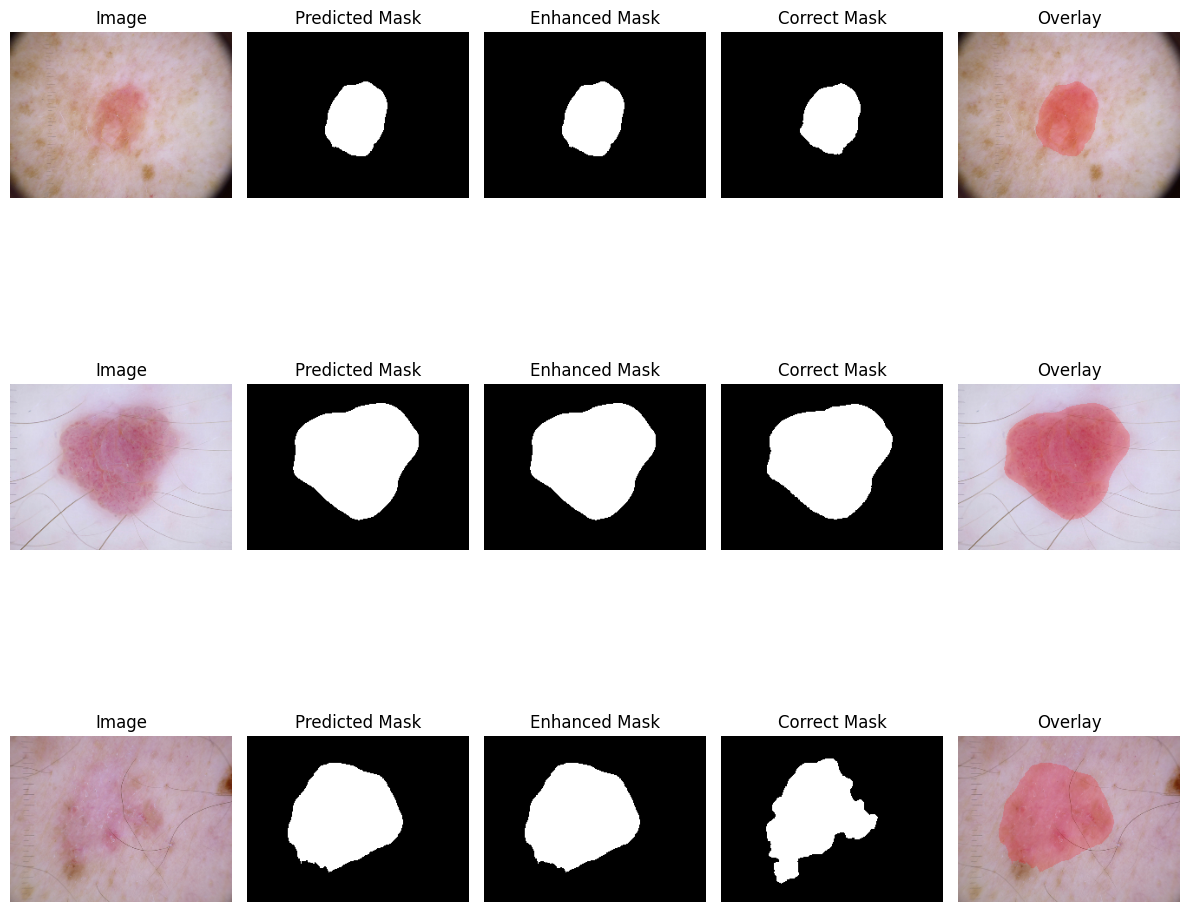

In [43]:
image_files = os.listdir(IMAGES_PATH)
random_images = random.sample(image_files, NUM_SAMPLES)

fig, axes = plt.subplots(NUM_SAMPLES, 5, figsize=FIGSIZE)

for i, filename in enumerate(random_images):
    # Fetch the image and the mask of the corresponding file path
    image_path = os.path.join(IMAGES_PATH, filename)
    annotated_mask_path = os.path.join(MASKS_PATH, filename.replace('.jpg','') + "_segmentation.png")

    # Ensure image is in RGB format, and convert image and mask to np arrays
    image = np.array(Image.open(image_path).convert("RGB"))
    annotated_mask = np.array(Image.open(annotated_mask_path).convert("L"), dtype=np.float32)
    annotated_mask[annotated_mask > 0] = 1.0

    # Apply transformations to the image and the mask
    transformations = get_validation_transformations()(image=image, mask=annotated_mask)
    transformed_image = transformations["image"]
    transformed_mask = transformations["mask"]

    # Predict mask
    predicted_mask = evaluate_model_on_image(image=transformed_image, model=test_model)

    # Enhance prediction
    enhanced_mask = enhance_prediction_mask(predicted_mask)

    # Convert tensor to numpy
    image = transformed_image.permute(1, 2, 0).cpu().numpy()
    if image.max() > 1.0:
        image /= 255.0

    # Create red overlay
    red_overlay = np.zeros_like(image)
    red_overlay[..., 0] = 1.0  # Red channel only

    overlay = np.where(predicted_mask[..., None] > 0.5,
                       (1 - ALPHA) * image + ALPHA * red_overlay,
                       image)

    # Plot: image, raw pred, ground truth, overlay, enhanced mask
    titles = ["Image", "Predicted Mask", "Enhanced Mask", "Correct Mask", "Overlay"]
    visuals = [image, predicted_mask, enhanced_mask, transformed_mask.squeeze(), overlay]

    for j in range(5):
        axes[i, j].imshow(visuals[j], cmap="gray" if j in [1, 2, 3] else None)
        axes[i, j].set_title(titles[j])
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()